# 5.Exploratory Data Analysis and Visualization

1. **Crypto Market Index (median of normalized prices)** — shows the 2022 regime shift.
2. **Market Index vs Average Sentiment (30‑day rolling)** — shows sentiment co‑moving with macro cycles.
3. **30‑Day Rolling Volatility** — shows risk/uncertainty clustering during stress periods.
4. **Cross‑Asset Dispersion by Regime (boxplot)** — shows synchronized movement during the crash vs divergence during recovery.

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

CLEAN_DIR = "data/clean"


## Load and combine cleaned asset files

We load all cleaned CSVs, tag each row with its asset symbol (from filename), and concatenate into one dataframe.


In [9]:
all_dfs = []

for file in os.listdir(CLEAN_DIR):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(CLEAN_DIR, file))
        df["asset"] = file.replace(".csv", "")
        all_dfs.append(df)

full_df = pd.concat(all_dfs, ignore_index=True)

full_df["Date"] = pd.to_datetime(full_df["Date"])
full_df = full_df.sort_values(["asset", "Date"])

full_df.head()


,Date,Close,High,Low,Open,Volume,sentiment_score_mean,sentiment_polarity_mean,sentiment_subjectivity_mean,news_count,...,return,log_return,vol_7d,vol_30d,ma_7,ma_30,ma_ratio,next_close,price_increase,asset
0,2021-10-12,283.827087,290.794342,271.140137,290.794342,257105772,1.0,0.16,0.50,1,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,300.959137,1.0,aave
1,2021-10-15,300.959137,304.683075,292.998596,303.687103,236993017,0.0,0.00,0.00,1,...,0.060361,0.058609,0.0,0.0,0.0,0.0,0.0,294.111298,0.0,aave
2,2021-10-18,294.111298,308.103485,290.353119,304.445831,180842395,1.0,0.14,0.45,1,...,-0.022753,-0.023016,0.0,0.0,0.0,0.0,0.0,303.545258,1.0,aave
3,2021-10-19,303.545258,304.241455,292.902893,294.190277,185299776,1.0,0.10,0.40,1,...,0.032076,0.031572,0.0,0.0,0.0,0.0,0.0,324.772034,1.0,aave
4,2021-10-27,324.772034,454.274536,324.571930,329.035248,2820519212,0.0,0.00,0.00,1,...,0.069930,0.067593,0.0,0.0,0.0,0.0,0.0,327.745483,1.0,aave


## Feature used for market‑level visuals: normalized price

To compare assets on a common scale, we normalize each asset's close price by its first available close:

**Normalized price at time t = Close price at time t / Close price at time 0**

This turns every asset into an index starting at 1.0 on the first date, this way we can compare growth patterns across different cryptocurrencies, even if their raw prices are very different.


In [10]:
full_df["normalized_price"] = full_df["Close"] / full_df.groupby("asset")["Close"].transform("first")

# Market index = median normalized price across assets
market_index = (
    full_df.groupby("Date")["normalized_price"]
    .median()
    .reset_index()
)

market_index.head()


,Date,normalized_price
0,2021-10-12,1.000000
1,2021-10-15,1.036275
2,2021-10-18,1.027176
3,2021-10-19,1.051402
4,2021-10-27,1.018335


## Figure 1 — Crypto Market Index (Median of Normalized Prices)

**What should the reader learn from this?**

The figure reveals a clear structural shift in 2022. The market peaked in late 2021, followed by a prolonged decline throughout 2022. Prices stabilized and began recovering in 2023, though not to previous highs.

**Key takeaway:** The crypto market experienced a broad and persistent structural break in 2022.


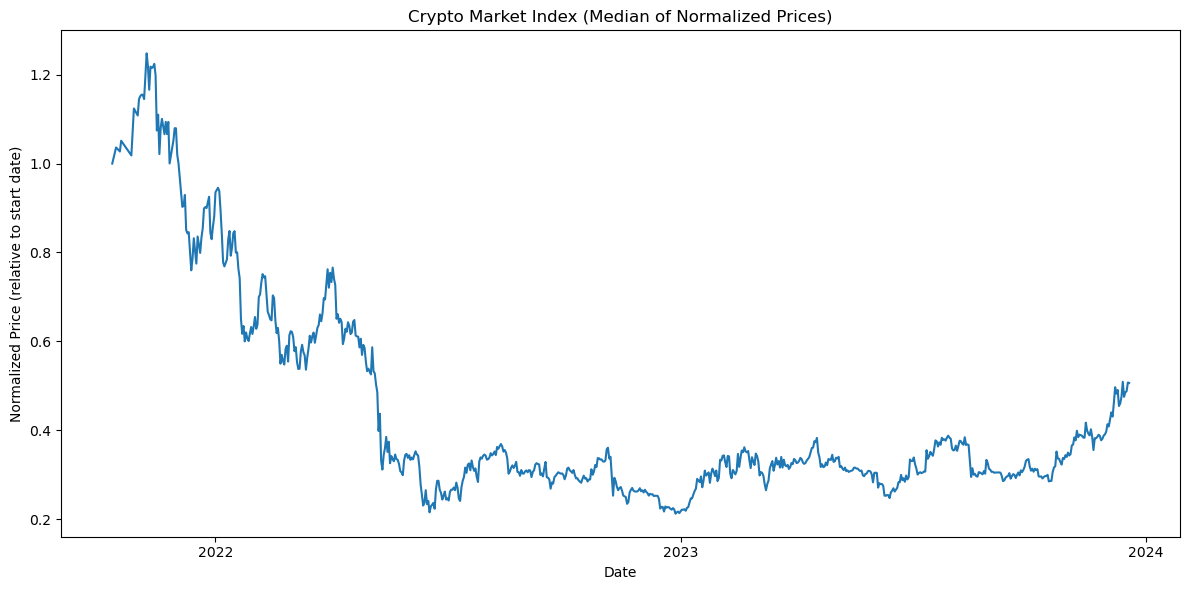

In [4]:
plt.figure(figsize=(12,6))
plt.plot(market_index["Date"], market_index["normalized_price"])
plt.title("Crypto Market Index (Median of Normalized Prices)")
plt.ylabel("Normalized Price (relative to start date)")
plt.xlabel("Date")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("fig1_market_index.png", dpi=300, bbox_inches="tight")
plt.show()


## Figure 2 — Market Index vs Average Sentiment (30‑Day Rolling)

**What should the reader learn from this?**

We compare the **30‑day rolling** market index against the **30‑day rolling average sentiment** across assets.  
Sentiment appears to co-move with macro price cycles. As the market declined in 2022, average sentiment also trended downward. During recovery in 2023, sentiment improved alongside prices. However, sentiment movements appear smoother relative to price movements, suggesting that sentiment may reflect broader market conditions  

**Key takeaway:** Sentiment tracks macro market cycles, reinforcing that the 2022 crash coincided with deteriorating overall market confidence.


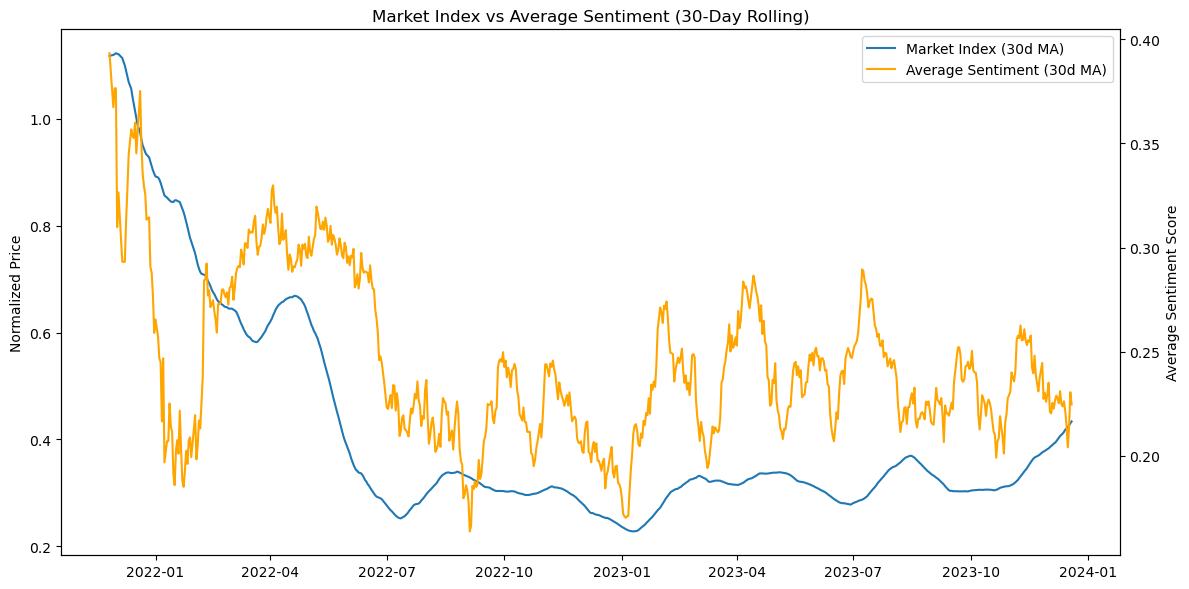

In [14]:
# Daily average sentiment across assets
daily_sentiment = (
    full_df.groupby("Date")["sentiment_score_mean"]
    .mean()
    .reset_index()
)

# Smooth both series
market_index_smooth = market_index.copy()
market_index_smooth["market_30d_ma"] = market_index_smooth["normalized_price"].rolling(30).mean()
daily_sentiment["sentiment_30d_ma"] = daily_sentiment["sentiment_score_mean"].rolling(30).mean()

fig, ax1 = plt.subplots(figsize=(12,6))

# Market index (left axis)
ax1.plot(market_index_smooth["Date"], market_index_smooth["market_30d_ma"], label="Market Index (30d MA)")
ax1.set_ylabel("Normalized Price")

# Sentiment (right axis)
ax2 = ax1.twinx()
ax2.plot(daily_sentiment["Date"], daily_sentiment["sentiment_30d_ma"], color="orange", label="Average Sentiment (30d MA)")
ax2.set_ylabel("Average Sentiment Score")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Market Index vs Average Sentiment (30-Day Rolling)")
plt.tight_layout()
plt.savefig("fig2_market_vs_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()


## Figure 3 — 30‑Day Rolling Volatility of the Crypto Market Index

**What should the reader learn from this?**

We compute market‑level log returns and then the **30‑day rolling standard deviation** (volatility).  
Volatility increased significantly during the 2022 downturn, indicating the market had a lot of uncertainty and risk. After the crash period, volatility gradually declined in 2023, suggesting stabilization.

**Key takeaway:** This behavior is consistent with financial markets during crisis period, where risk clusters and price movements become more extreme. The 2022 drop was characterized not only by falling prices but also by elevated systemic risk.


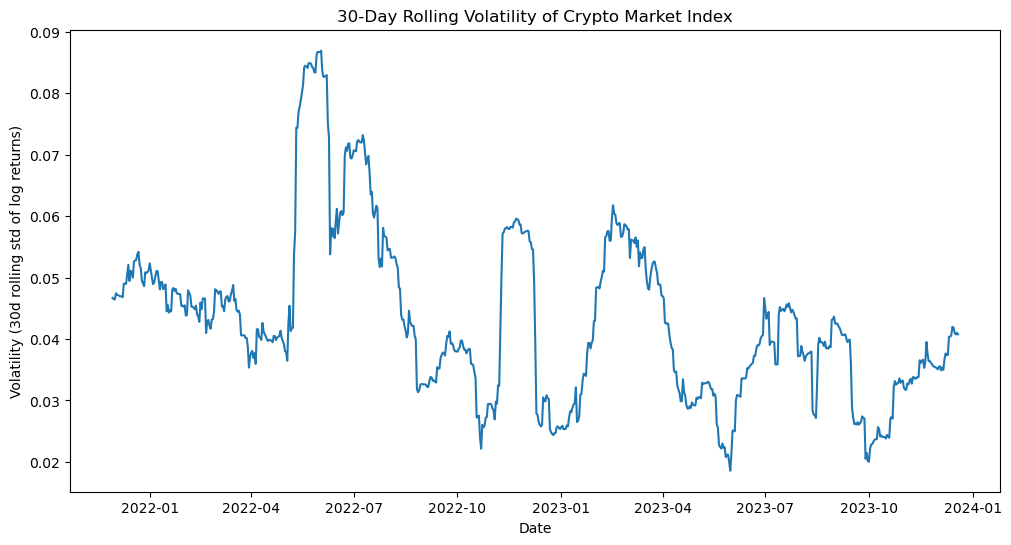

In [16]:
market_index = market_index.sort_values("Date").copy()

# Market log returns
market_index["log_return"] = np.log(
    market_index["normalized_price"] / market_index["normalized_price"].shift(1)
)

# 30-day rolling volatility
market_index["vol_30d"] = market_index["log_return"].rolling(30).std()

vol_df = market_index.dropna(subset=["vol_30d"])

plt.figure(figsize=(12,6))
plt.plot(vol_df["Date"], vol_df["vol_30d"])
plt.title("30-Day Rolling Volatility of Crypto Market Index")
plt.ylabel("Volatility (30d rolling std of log returns)")
plt.xlabel("Date")
plt.savefig("fig3_rolling_volatility.png", dpi=300, bbox_inches="tight")
plt.show()


## Figure 4 — Cross‑Asset Dispersion by Market Period

**What should the reader learn from this?**

Cross‑asset dispersion measures how spread out asset performances are on a given day.  
We compute daily dispersion as the **interquartile range (IQR)** of normalized prices across assets:

Dispersion at time t = 75th percentile of normalized prices at time t − 25th percentile of normalized prices at time t
                     = Q3 - Q1

We then compare dispersion across three period:
- **Pre‑Crash:** before 2022‑04‑01  
- **Crash 2022:** 2022‑04‑01 to 2022‑12‑31  
- **Recovery 2023:** 2023‑01‑01 onward  

Lower dispersion suggests assets moved **more uniformly** while higher dispersion suggests assets **diverged** (some recovered faster than others).
During the Crash 2022 period, cross-asset dispersion is lower relative to the recovery period. This suggests that assets moved more uniformly during the downturn, showing synchronized declines. In contrast, dispersion increases during Recovery 2023. This indicates that assets diverged in performance, with some recovering faster than others.

**Key takeaway:** dispersion is lower during the crash (more synchronized declines) and higher during recovery (more differentiated performance).


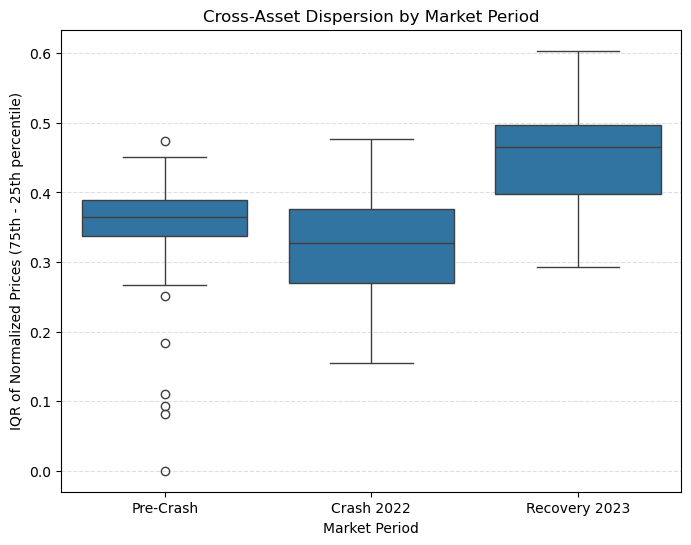

In [18]:
# Daily cross-asset dispersion (IQR of normalized prices)
dispersion = (
    full_df.groupby("Date")["normalized_price"]
    .agg(iqr=lambda x: x.quantile(0.75) - x.quantile(0.25))
    .reset_index()
)

dispersion["period"] = "Other"
dispersion.loc[dispersion["Date"] < "2022-04-01", "period"] = "Pre-Crash"
dispersion.loc[(dispersion["Date"] >= "2022-04-01") & (dispersion["Date"] < "2023-01-01"), "period"] = "Crash 2022"
dispersion.loc[dispersion["Date"] >= "2023-01-01", "period"] = "Recovery 2023"

order = ["Pre-Crash", "Crash 2022", "Recovery 2023"]

plt.figure(figsize=(8,6))
sns.boxplot(x="period", y="iqr", data=dispersion, order=order)
plt.title("Cross-Asset Dispersion by Market Period")
plt.ylabel("IQR of Normalized Prices (75th - 25th percentile)")
plt.xlabel("Market Period")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.savefig("fig4_dispersion_by_period.png", dpi=300, bbox_inches="tight")
plt.show()
